# 4-1. LangGraph State, Node, Edge

## 학습 목표

- LangGraph의 `State`, `Node`, `Edge` 개념을 이해한다.
- 아주 간단한 그래프를 직접 만든다.

In [7]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## 1. State 정의

State는 그래프 전체에서 공유되는 데이터 구조다.

In [8]:
class DemoState(TypedDict):
    question: str   # 사용자 질문 (입력)
    answer:   str   # 생성된 답변 (출력)


## 2. Node 함수 정의

Node는 State를 입력받아 State의 일부를 반환하는 함수다.

In [9]:
def answer_node(state: DemoState) -> dict:
    """질문을 받아 간단한 답변을 생성하는 노드."""
    question = state["question"]
    return {
        "answer": f"입력한 질문은 '{question}'입니다."
    }

## 3. Graph 구성

In [10]:
# 1. 빌더 생성 (State 타입 지정)
graph = StateGraph(DemoState)

# 2. 노드 등록
graph.add_node("answer_node", answer_node)

# 3. 엣지 연결 (실행 순서 정의)
graph.add_edge(START, "answer_node")  # 시작 → answer_node
graph.add_edge("answer_node", END)    # answer_node → 종료

# 4. 컴파일
app = graph.compile()


## 4. Graph 그리기

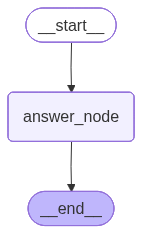

In [11]:
from IPython.display import Image, display

def show_graph(app) -> None:
    """LangGraph 그래프를 이미지로 출력하고, 실패하면 ASCII로 대체한다."""
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())

show_graph(app)


## 5. Graph 실행

In [12]:
result = app.invoke({
    "question": "LangGraph는 무엇인가요?"
})

result

{'question': 'LangGraph는 무엇인가요?', 'answer': "입력한 질문은 'LangGraph는 무엇인가요?'입니다."}

## 핵심 정리

```python
StateGraph(State)
add_node("노드명", 함수)
add_edge(START, "노드명")
add_edge("노드명", END)
compile()
invoke({"question": "질문"})
```

- State: 그래프가 공유하는 데이터
- Node: 실제 작업을 수행하는 함수
- Edge: 다음 실행 노드를 연결하는 흐름